# CuRIOS FITS Imaging - Version 2.8

This notebook demonstrates the standard workflow for analyzing a CuRIOS FITS image.

Workflow:

1. Configure analysis parameters
2. Select an observing folder and image
3. Analyze the image
4. Display the standard report
5. (Optional) Run additional diagnostics

For advanced examples, see the notebooks in the `examples/` directory.

In [1]:
from pathlib import Path

from fits_imaging.config import ImagingConfig
from fits_imaging.analysis import analyze_image
from fits_imaging.session import ImagingSession

In [3]:
data_root = Path(
    "/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories"
).expanduser().resolve()

if not data_root.exists():
    raise FileNotFoundError(f"Data directory does not exist: {data_root}")

config = ImagingConfig()
config.data_root = data_root

config.colormap = "viridis"
config.contrast_method = "sigma"
config.contrast_sigma_low = 1.0
config.contrast_sigma_high = 5.0
config.stretch = "linear"

session = ImagingSession(data_root=data_root)

print("Data root:", session.data_root)
print("State file:", session.state_path)
print("Configuration updated")

Data root: /Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories
State file: /Users/svwbeckwith/.config/curios-fits-imaging/session.json
Configuration updated


In [5]:
selected_folder = session.choose_folder()

print("Selected folder:", selected_folder)


Folder#   Folder
------------------------------------------------------------
   0     Archive
   1     CowTests
   2     Figures
   3     Icons
   4     Images
   5     Lib-0610
   6     Logs
   7     Patio-0629
   8     Patio-0703
   9     Patio-0720
  10     Patio-0725
  11     Patio-0726



Choose folder number:  11


Selected folder: /Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories/Patio-0726


In [7]:
print("Current folder:", session.current_folder)

if session.current_folder is None:
    raise RuntimeError("No observing folder was selected.")

Current folder: /Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories/Patio-0726


In [9]:
image_path = session.choose_image()

print("Selected image:", image_path)


File#       File
----------------------------------------------------------------------
    0       Alkaid_2026-07-27_04.00.51_CuED-0.fits
    1       Altair_2026-07-27_04.11.14_CuED_5_sum.fits
    2       Antares_2026-07-27_04.05.13_CuED_5_sum.fits
    3       Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits
    4       Deneb_2026-07-27_04.13.59_CuED_5_sum.fits
    5       Dubhe_2026-07-27_03.56.42_CuED-0.fits
    6       Polaris_2026-07-27_03.52.41_CuED_5_sum.fits
    7       Spica_2026-07-27_03.58.00_CuED_5_sum.fits
    8       Vega_2026-07-27_04.08.06_CuED_5_sum.fits
----------------------------------------------------------------------


Enter file number to analyze:  7


Selected image: /Users/svwbeckwith/Library/CloudStorage/Dropbox/CuRIOS/Software/DataDirectories/Patio-0726/Spica_2026-07-27_03.58.00_CuED_5_sum.fits


In [11]:
results = analyze_image(image_path, config)

print("Analysis complete")

Analysis complete


Spica  9576 x 6380  Apx60-CuED  0.020 sec
RAH:  13.420  Dec: -11.161  PA:  35.68  PA2: -35.68  Alt:    28.0  Az:   226.4
Mean: 537.4  Median: 538.0  Std: 22.1  Min: 32.0  Max: 7627.0
Found 3 peaks in 2.91 sec

Source statistics:
{'nstars': 3, 'median_fwhm': 9.528467178344727, 'median_flux': 125103.0, 'brightest_flux': 321807.0}

Selected-region source statistics:
{'nstars': 2, 'median_fwhm': 11.347773551940918, 'median_flux': 223455.0, 'brightest_flux': 321807.0}


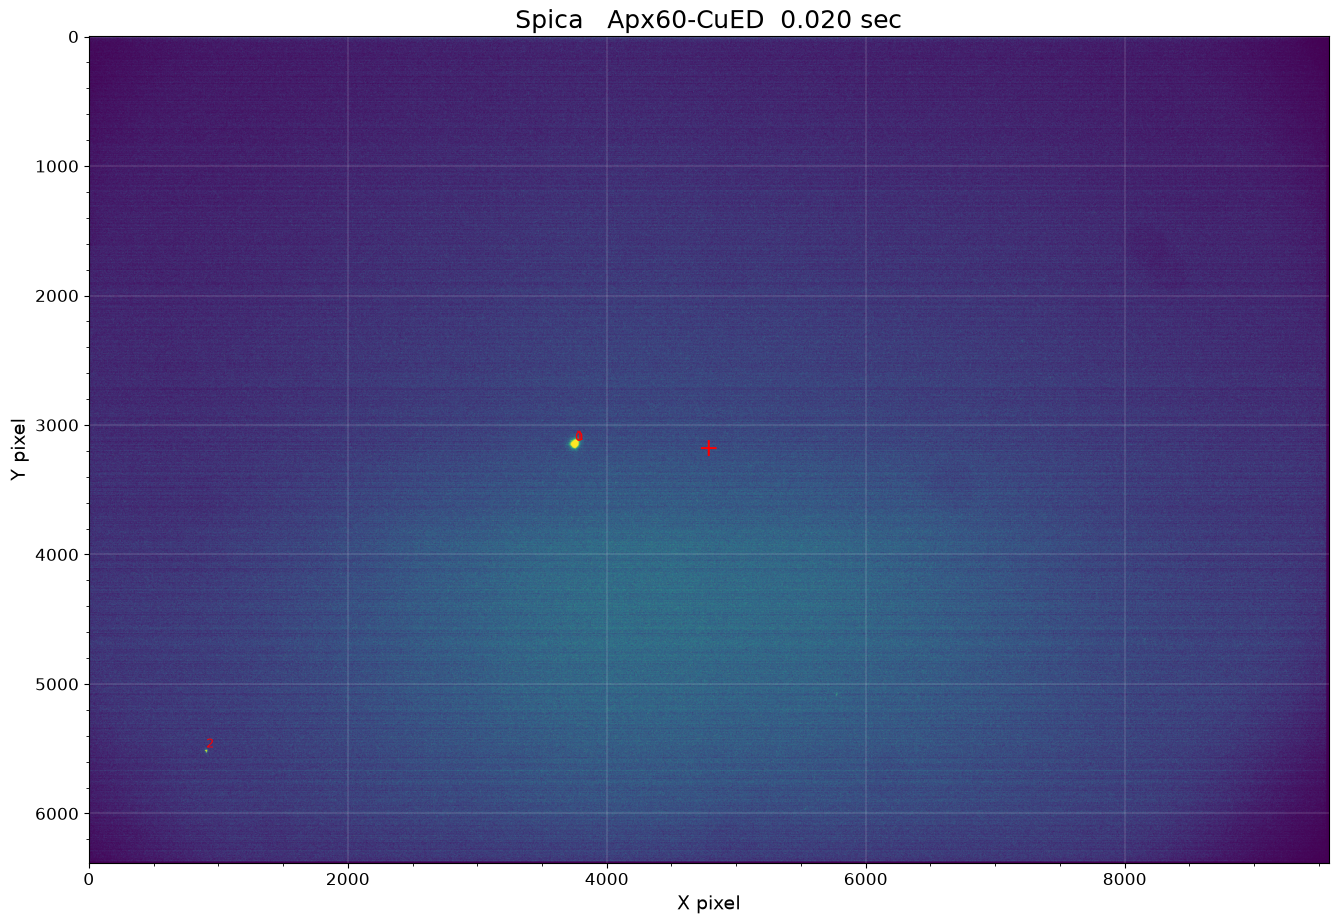


Peak#        X        Y        Area       sx      sy        Flux      Mag
------------------------------------------------------------------------------
    0   3754.82   3146.13    494184.1    4.19    3.28    321807.0    2.135
    1   3759.39   3137.24    377764.7    5.92    5.89    125103.0    3.161
    2    905.45   5513.68      9567.6    4.59    3.51      5575.0    6.539


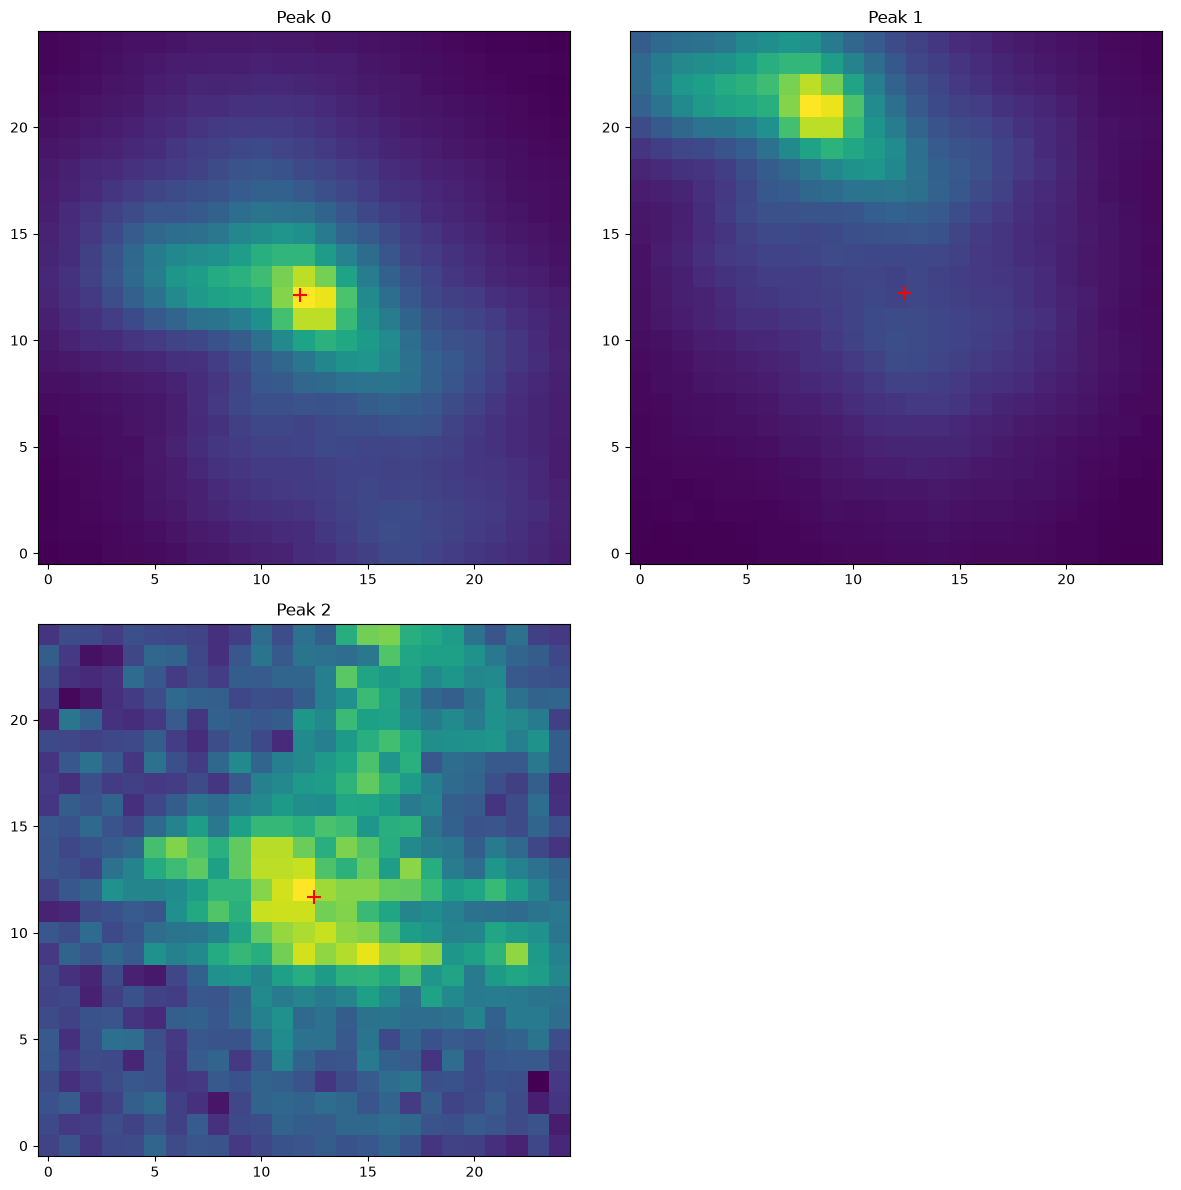

In [13]:
results.report(
    config=config,
    show_summary=True,
    show_image=True,
    show_table=True,
    show_cutouts=True,
    show_histogram=False,
    show_statistics=True,
)

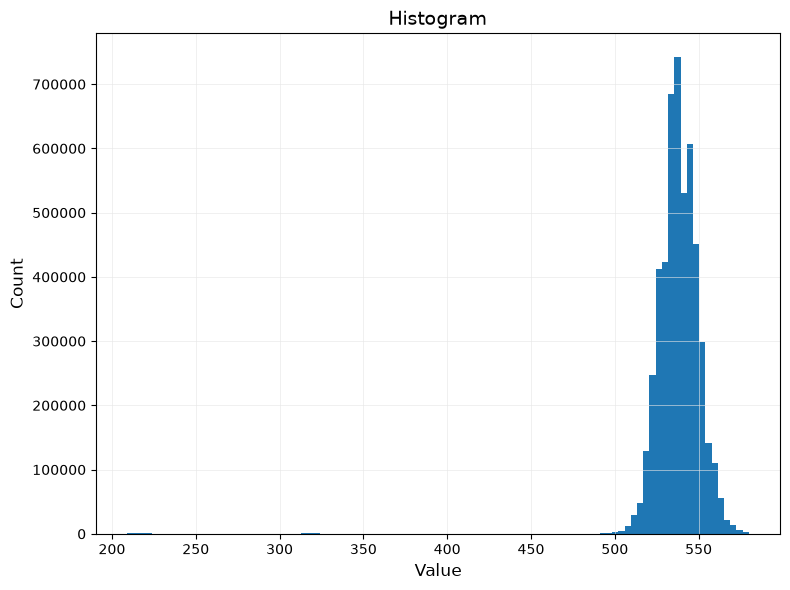

In [15]:
import matplotlib.pyplot as plt
results.plot_histogram(config=config)
plt.show()

In [17]:
results.source_statistics()

{'nstars': 3,
 'median_fwhm': 9.528467178344727,
 'median_flux': 125103.0,
 'brightest_flux': 321807.0}

In [19]:
batch_results, batch_summary = session.analyze_current_folder(
    config,
    max_files=10,
)

batch_summary

[1/9] Alkaid_2026-07-27_04.00.51_CuED-0.fits
[2/9] Altair_2026-07-27_04.11.14_CuED_5_sum.fits
[3/9] Antares_2026-07-27_04.05.13_CuED_5_sum.fits
[4/9] Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits
[5/9] Deneb_2026-07-27_04.13.59_CuED_5_sum.fits
[6/9] Dubhe_2026-07-27_03.56.42_CuED-0.fits
[7/9] Polaris_2026-07-27_03.52.41_CuED_5_sum.fits
[8/9] Spica_2026-07-27_03.58.00_CuED_5_sum.fits
[9/9] Vega_2026-07-27_04.08.06_CuED_5_sum.fits


,file,object,camera,exposure_sec,nstars,median_fwhm_pixels,background_median,background_sigma,peak_find_time_sec
0,Alkaid_2026-07-27_04.00.51_CuED-0.fits,Alkaid,Apx60-CuED,0.010,2,7.343746,108.0,5.866696,3.831756
1,Altair_2026-07-27_04.11.14_CuED_5_sum.fits,Altair,Apx60-CuED,0.015,2,3.950277,494.0,17.276219,3.830803
2,Antares_2026-07-27_04.05.13_CuED_5_sum.fits,Antares,Apx60-CuED,0.020,5,8.870814,503.0,20.413080,3.910588
3,Arcturus_2026-07-27_04.02.03_CuED_5_sum.fits,Arcturus,Apx60-CuED,0.005,8,1.682539,494.0,16.866729,3.844460
4,Deneb_2026-07-27_04.13.59_CuED_5_sum.fits,Deneb,Apx60-CuED,0.025,30,1.571725,494.0,11.645672,3.941532
5,Dubhe_2026-07-27_03.56.42_CuED-0.fits,Dubhe,Apx60-CuED,0.009,1,10.622739,140.0,9.749600,3.858742
6,Polaris_2026-07-27_03.52.41_CuED_5_sum.fits,Polaris,Apx60-CuED,0.060,1,11.397878,862.0,47.913969,3.812644
7,Spica_2026-07-27_03.58.00_CuED_5_sum.fits,Spica,Apx60-CuED,0.020,3,9.528467,538.0,22.084392,3.885565
8,Vega_2026-07-27_04.08.06_CuED_5_sum.fits,Vega,Apx60-CuED,0.005,19,1.434802,492.0,11.982880,3.939673


In [14]:
batch_summary.to_csv("batch_summary.csv", index=False)

In [15]:
run = session.open_run()

len(run.files), run.folder

(63,
 PosixPath('/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories/Patio-0629'))

In [16]:
summary = run.analyze_all(config, max_files=5)
summary

[1/5] Altair-Bahtinov_2026-06-29_08.15.59_CuED-0.fits
[2/5] Altair-Bahtinov_2026-06-29_08.15.59_CuED_0_sum.fits
[3/5] Altair-Bahtinov_2026-06-29_08.21.48_CuED-0.fits
[4/5] Altair-Bahtinov_2026-06-29_08.26.49_CuED-0.fits
[5/5] M15_2026-06-29_10.20.58_CuED_10_sum.fits


/Users/svwbeckwith/Dropbox/CuRIOS/Software/Python/curios-fits-imaging/fits_imaging/peak_finding.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian2d, (X, Y), sub.ravel(), p0=p0, maxfev=200)


,file,path,object,camera,exposure_sec,nstars,median_fwhm_pixels,median_background,background_sigma,brightest_flux,peak_find_time_sec,stats_region
0,Altair-Bahtinov_2026-06-29_08.15.59_CuED-0.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.05,21,7.965293,100.0,6.825011,268163.0,3.632761,center_fraction
1,Altair-Bahtinov_2026-06-29_08.15.59_CuED_0_sum...,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.00,0,NaN,0.0,0.000000,NaN,2.423809,center_fraction
2,Altair-Bahtinov_2026-06-29_08.21.48_CuED-0.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.05,21,8.693119,100.0,7.307320,291727.0,3.682212,center_fraction
3,Altair-Bahtinov_2026-06-29_08.26.49_CuED-0.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.05,21,8.205919,100.0,8.037762,336186.0,3.627451,center_fraction
4,M15_2026-06-29_10.20.58_CuED_10_sum.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,M15,Apx60-CuED,10.00,491,5.421201,1454.0,139.243675,1468456.0,4.302325,center_fraction


In [11]:
run.best_by_stars()

,file,path,object,camera,exposure_sec,nstars,median_fwhm_pixels,median_background,background_sigma,brightest_flux,peak_find_time_sec,stats_region
4,M15_2026-06-29_10.20.58_CuED_10_sum.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,M15,Apx60-CuED,10.00,491,5.421201,1454.0,139.243675,1468456.0,4.253157,center_fraction
0,Altair-Bahtinov_2026-06-29_08.15.59_CuED-0.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.05,21,7.965293,100.0,6.825011,268163.0,3.562065,center_fraction
2,Altair-Bahtinov_2026-06-29_08.21.48_CuED-0.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.05,21,8.693119,100.0,7.307320,291727.0,3.578131,center_fraction
3,Altair-Bahtinov_2026-06-29_08.26.49_CuED-0.fits,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.05,21,8.205919,100.0,8.037762,336186.0,3.511902,center_fraction
1,Altair-Bahtinov_2026-06-29_08.15.59_CuED_0_sum...,/Users/svwbeckwith/Dropbox/CuRIOS/Software/Dat...,Altair-Bahtinov,Apx60-CuED,0.00,0,NaN,0.0,0.000000,NaN,2.383633,center_fraction
